# Modele Multi-Tache V3 - Version Equilibree

Ameliorations par rapport a V2:

- **Focal Loss** pour gerer le desequilibre des classes
- **Oversampling** des classes minoritaires
- **Poids de classes renforces**
- **Augmentation de donnees plus aggressive**
- **Label smoothing** pour meilleure generalisation


In [1]:
import os
import warnings

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from scipy import stats
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import CosineDecay
from tensorflow.keras.regularizers import l2
import tensorflow.keras.backend as K

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (12, 6), "axes.titlesize": 14})

print("Imports OK!")

TensorFlow version: 2.20.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Imports OK!


## Configuration


In [2]:
# Chemins
BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "data" / "UTKFace"
ARTIFACTS_DIR = BASE_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(exist_ok=True)

# Hyperparametres
IMG_SIZE = 128
BATCH_SIZE = 32
WARMUP_EPOCHS = 20
FINETUNE_EPOCHS = 50
INITIAL_LR = 1e-3
FINETUNE_LR = 1e-5

# Splits
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

# Classes
ETHNICITY_CLASSES = ["White", "Black", "Asian", "Indian", "Others"]
GENDER_CLASSES = ["Male", "Female"]

print(f"Configuration:")
print(f"  - Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  - Batch size: {BATCH_SIZE}")

Configuration:
  - Image size: 128x128
  - Batch size: 32


## Chargement des Donnees


In [3]:
def parse_utkface_filename(filepath):
    """Parse le nom de fichier UTKFace: [age]_[gender]_[race]_[date&time].jpg"""
    filename = Path(filepath).stem
    parts = filename.split("_")

    if len(parts) >= 3:
        try:
            age = int(parts[0])
            gender = int(parts[1])  # 0: Male, 1: Female
            ethnicity = int(parts[2])  # 0-4

            if 0 <= age <= 116 and gender in [0, 1] and 0 <= ethnicity <= 4:
                return {
                    "filepath": str(filepath),
                    "age": age,
                    "gender": gender,
                    "ethnicity": ethnicity,
                }
        except (ValueError, IndexError):
            pass
    return None


# Charger toutes les images
image_paths = list(DATA_DIR.glob("*.jpg")) + list(DATA_DIR.glob("*.JPG"))
print(f"Images trouvees: {len(image_paths)}")

records = []
for path in tqdm(image_paths, desc="Parsing filenames"):
    record = parse_utkface_filename(path)
    if record:
        records.append(record)

df = pd.DataFrame(records)
print(f"\nImages valides: {len(df)}")

# Afficher la distribution
print(f"\nDistribution des genres:")
print(df["gender"].value_counts())
print(f"\nDistribution des ethnicites:")
print(df["ethnicity"].value_counts())

Images trouvees: 23708


Parsing filenames: 100%|██████████| 23708/23708 [00:00<00:00, 325076.28it/s]


Images valides: 23705

Distribution des genres:
gender
0    12391
1    11314
Name: count, dtype: int64

Distribution des ethnicites:
ethnicity
0    10078
1     4526
3     3975
2     3434
4     1692
Name: count, dtype: int64


## Nettoyage et Oversampling


In [4]:
# Retirer les outliers d'age (Z-score > 3)
z_scores = np.abs(stats.zscore(df["age"]))
outliers_mask = z_scores > 3
df_clean = df[~outliers_mask].copy()
print(f"Dataset apres nettoyage: {len(df_clean)} images")

# Oversampling des classes minoritaires pour l'ethnicite
# On va dupliquer les images des classes sous-representees
eth_counts = df_clean["ethnicity"].value_counts()
max_count = eth_counts.max()
target_count = int(max_count * 0.7)  # On cible 70% de la classe majoritaire

print(f"\nComptes originaux par ethnicite:")
print(eth_counts)
print(f"\nTarget count: {target_count}")

df_balanced = df_clean.copy()
for eth in range(5):
    current_count = eth_counts.get(eth, 0)
    if current_count < target_count:
        # Nombre d'echantillons a ajouter
        n_to_add = target_count - current_count
        # Selectionner aleatoirement des echantillons a dupliquer
        samples_to_duplicate = df_clean[df_clean["ethnicity"] == eth].sample(
            n=n_to_add, replace=True, random_state=SEED
        )
        df_balanced = pd.concat([df_balanced, samples_to_duplicate], ignore_index=True)
        print(
            f"  Ethnicite {eth} ({ETHNICITY_CLASSES[eth]}): {current_count} -> {current_count + n_to_add}"
        )

print(f"\nDataset apres oversampling: {len(df_balanced)} images")
print(f"\nNouvelle distribution des ethnicites:")
print(df_balanced["ethnicity"].value_counts().sort_index())

Dataset apres nettoyage: 23633 images

Comptes originaux par ethnicite:
ethnicity
0    10034
1     4520
3     3972
2     3415
4     1692
Name: count, dtype: int64

Target count: 7023
  Ethnicite 1 (Black): 4520 -> 7023
  Ethnicite 2 (Asian): 3415 -> 7023
  Ethnicite 3 (Indian): 3972 -> 7023
  Ethnicite 4 (Others): 1692 -> 7023

Dataset apres oversampling: 38126 images

Nouvelle distribution des ethnicites:
ethnicity
0    10034
1     7023
2     7023
3     7023
4     7023
Name: count, dtype: int64


## Split Train/Val/Test


In [5]:
# Utiliser df_balanced pour l'entrainement
X = df_balanced["filepath"].values
y_age = df_balanced["age"].values.astype(np.float32)
y_gender = df_balanced["gender"].values.astype(np.int32)
y_ethnicity = df_balanced["ethnicity"].values.astype(np.int32)

# Premier split: train+val vs test
(
    X_trainval,
    X_test,
    y_age_trainval,
    y_age_test,
    y_gender_trainval,
    y_gender_test,
    y_eth_trainval,
    y_eth_test,
) = train_test_split(
    X,
    y_age,
    y_gender,
    y_ethnicity,
    test_size=TEST_SPLIT,
    random_state=SEED,
    stratify=y_ethnicity,
)

# Deuxieme split: train vs val
val_ratio = VAL_SPLIT / (1 - TEST_SPLIT)
(
    X_train,
    X_val,
    y_age_train,
    y_age_val,
    y_gender_train,
    y_gender_val,
    y_eth_train,
    y_eth_val,
) = train_test_split(
    X_trainval,
    y_age_trainval,
    y_gender_trainval,
    y_eth_trainval,
    test_size=val_ratio,
    random_state=SEED,
    stratify=y_eth_trainval,
)

print(f"Split des donnees:")
print(f"  - Train: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  - Val: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"  - Test: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

Split des donnees:
  - Train: 26688 (70.0%)
  - Val: 5719 (15.0%)
  - Test: 5719 (15.0%)


## Calcul des Poids de Classes Renforces


In [6]:
# Poids pour le genre - renforcer Female
gender_counts = Counter(y_gender_train)
total_gender = sum(gender_counts.values())
gender_class_weights = {
    0: total_gender / (2 * gender_counts[0]),  # Male
    1: total_gender / (2 * gender_counts[1]) * 1.3,  # Female - boost de 30%
}
print(f"Poids des classes (genre): {gender_class_weights}")

# Poids pour l'ethnicite - renforcer fortement les minorites
eth_counts = Counter(y_eth_train)
total_eth = sum(eth_counts.values())
ethnicity_class_weights = {}
for eth in range(5):
    base_weight = total_eth / (5 * eth_counts.get(eth, 1))
    # Boost supplementaire pour les classes minoritaires
    if eth == 4:  # Others
        boost = 2.0
    elif eth == 2:  # Asian
        boost = 1.5
    elif eth == 3:  # Indian
        boost = 1.3
    else:
        boost = 1.0
    ethnicity_class_weights[eth] = base_weight * boost

print(f"Poids des classes (ethnicite): {ethnicity_class_weights}")

Poids des classes (genre): {0: 0.9795199295309404, 1: 1.3277611940298508}
Poids des classes (ethnicite): {0: 0.7599088838268793, 1: 1.0857607811228642, 2: 1.6286411716842963, 3: 1.4114890154597235, 4: 2.1715215622457285}


## Focal Loss Implementation


In [7]:
class FocalLoss(keras.losses.Loss):
    """Focal Loss pour gerer les classes desequilibrees."""

    def __init__(
        self, gamma=2.0, alpha=None, from_logits=False, label_smoothing=0.1, **kwargs
    ):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.alpha = alpha
        self.from_logits = from_logits
        self.label_smoothing = label_smoothing

    def call(self, y_true, y_pred):
        # Apply label smoothing
        num_classes = tf.shape(y_pred)[-1]
        y_true = tf.one_hot(tf.cast(y_true, tf.int32), num_classes)
        y_true = y_true * (1.0 - self.label_smoothing) + self.label_smoothing / tf.cast(
            num_classes, tf.float32
        )

        if self.from_logits:
            y_pred = tf.nn.softmax(y_pred)

        # Clip pour eviter log(0)
        y_pred = tf.clip_by_value(y_pred, K.epsilon(), 1.0 - K.epsilon())

        # Calcul de la focal loss
        cross_entropy = -y_true * tf.math.log(y_pred)
        focal_weight = tf.pow(1.0 - y_pred, self.gamma)
        focal_loss = focal_weight * cross_entropy

        return tf.reduce_mean(tf.reduce_sum(focal_loss, axis=-1))


class BinaryFocalLoss(keras.losses.Loss):
    """Binary Focal Loss pour la classification binaire."""

    def __init__(self, gamma=2.0, alpha=0.5, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, K.epsilon(), 1.0 - K.epsilon())

        # Focal loss components
        p_t = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
        alpha_t = tf.where(tf.equal(y_true, 1), self.alpha, 1 - self.alpha)

        focal_loss = -alpha_t * tf.pow(1 - p_t, self.gamma) * tf.math.log(p_t)

        return tf.reduce_mean(focal_loss)


print("Focal Loss implementee!")

Focal Loss implementee!


## Data Augmentation Renforcee


In [8]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.15),  # Augmente de 0.1 a 0.15
        layers.RandomZoom(0.2),  # Augmente de 0.15 a 0.2
        layers.RandomTranslation(0.15, 0.15),  # Augmente de 0.1 a 0.15
        layers.RandomBrightness(0.25),  # Augmente de 0.2 a 0.25
        layers.RandomContrast(0.25),  # Augmente de 0.2 a 0.25
    ],
    name="data_augmentation",
)

print("Data augmentation configuree (renforcee):")
for layer in data_augmentation.layers:
    print(f"  - {layer.name}")

I0000 00:00:1768911296.743513    5442 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4130 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Data augmentation configuree (renforcee):
  - random_flip
  - random_rotation
  - random_zoom
  - random_translation
  - random_brightness
  - random_contrast


## Pipeline de Donnees


In [9]:
def load_and_preprocess(filepath, age, gender, ethnicity):
    """Charge et pretraite une image."""
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)  # [0, 255]
    return img, {
        "age_output": age,
        "gender_output": gender,
        "ethnicity_output": ethnicity,
    }


def create_dataset(filepaths, ages, genders, ethnicities, training=False):
    """Cree un tf.data.Dataset."""
    ds = tf.data.Dataset.from_tensor_slices((filepaths, ages, genders, ethnicities))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.shuffle(buffer_size=2000)  # Augmente le buffer

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = create_dataset(
    X_train, y_age_train, y_gender_train, y_eth_train, training=True
)
val_ds = create_dataset(X_val, y_age_val, y_gender_val, y_eth_val, training=False)
test_ds = create_dataset(X_test, y_age_test, y_gender_test, y_eth_test, training=False)

print(f"Datasets crees:")
print(f"  - Train: {len(X_train)} images")
print(f"  - Val: {len(X_val)} images")
print(f"  - Test: {len(X_test)} images")

Datasets crees:
  - Train: 26688 images
  - Val: 5719 images
  - Test: 5719 images


## Architecture du Modele


In [10]:
def build_multitask_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), training=True):
    """Construit le modele multi-tache avec architecture amelioree."""

    inputs = layers.Input(shape=input_shape, name="input_image")

    x = data_augmentation(inputs) if training else inputs

    # Backbone: EfficientNetB0
    backbone = EfficientNetB0(include_top=False, weights="imagenet", input_tensor=x)
    backbone.trainable = False

    features = backbone.output

    # Double pooling
    gap = layers.GlobalAveragePooling2D(name="gap")(features)
    gmp = layers.GlobalMaxPooling2D(name="gmp")(features)
    pooled = layers.Concatenate(name="concat_pooling")([gap, gmp])

    # Couches partagees plus larges
    shared = layers.Dense(
        512, activation="relu", kernel_regularizer=l2(1e-4), name="shared_dense1"
    )(pooled)
    shared = layers.BatchNormalization(name="shared_bn1")(shared)
    shared = layers.Dropout(0.4, name="shared_dropout1")(shared)

    shared = layers.Dense(
        256, activation="relu", kernel_regularizer=l2(1e-4), name="shared_dense2"
    )(shared)
    shared = layers.BatchNormalization(name="shared_bn2")(shared)
    shared = layers.Dropout(0.3, name="shared_dropout2")(shared)

    # === HEAD AGE (Regression) ===
    age_branch = layers.Dense(
        128, activation="relu", kernel_regularizer=l2(1e-4), name="age_dense1"
    )(shared)
    age_branch = layers.BatchNormalization(name="age_bn")(age_branch)
    age_branch = layers.Dropout(0.3, name="age_dropout")(age_branch)
    age_output = layers.Dense(1, activation="linear", name="age_output")(age_branch)

    # === HEAD GENRE (Classification binaire) ===
    gender_branch = layers.Dense(
        128, activation="relu", kernel_regularizer=l2(1e-4), name="gender_dense1"
    )(shared)
    gender_branch = layers.BatchNormalization(name="gender_bn")(gender_branch)
    gender_branch = layers.Dropout(0.3, name="gender_dropout")(gender_branch)
    gender_output = layers.Dense(1, activation="sigmoid", name="gender_output")(
        gender_branch
    )

    # === HEAD ETHNICITE (Classification multi-classe) ===
    ethnicity_branch = layers.Dense(
        256, activation="relu", kernel_regularizer=l2(1e-4), name="ethnicity_dense1"
    )(shared)
    ethnicity_branch = layers.BatchNormalization(name="ethnicity_bn1")(ethnicity_branch)
    ethnicity_branch = layers.Dropout(0.4, name="ethnicity_dropout1")(ethnicity_branch)
    ethnicity_branch = layers.Dense(
        128, activation="relu", kernel_regularizer=l2(1e-4), name="ethnicity_dense2"
    )(ethnicity_branch)
    ethnicity_branch = layers.BatchNormalization(name="ethnicity_bn2")(ethnicity_branch)
    ethnicity_branch = layers.Dropout(0.3, name="ethnicity_dropout2")(ethnicity_branch)
    ethnicity_output = layers.Dense(5, activation="softmax", name="ethnicity_output")(
        ethnicity_branch
    )

    model = Model(
        inputs=inputs,
        outputs=[age_output, gender_output, ethnicity_output],
        name="multitask_face_model_v3",
    )

    return model, backbone


model, backbone = build_multitask_model(training=True)
model.summary()

Model: "multitask_face_model_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 128, 128,  │          0 │ input_image[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 128, 128,  │          0 │ data_augmentatio… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 128, 128,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 128, 128,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 129, 129,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 64, 64,    │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 64, 64,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 64, 64,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 64, 64,    │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 64, 64,    │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 64, 64,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 64, 64,    │          0 │ block1a_activati

 Total params: 5,663,146 (21.60 MB)

 Trainable params: 1,610,759 (6.14 MB)

 Non-trainable params: 4,052,387 (15.46 MB)

## Compilation avec Focal Loss


In [11]:
steps_per_epoch = len(X_train) // BATCH_SIZE
total_warmup_steps = steps_per_epoch * WARMUP_EPOCHS

warmup_lr_schedule = CosineDecay(
    initial_learning_rate=INITIAL_LR, decay_steps=total_warmup_steps, alpha=0.1
)

# Losses avec Focal Loss
losses = {
    "age_output": keras.losses.Huber(delta=5.0),
    "gender_output": BinaryFocalLoss(gamma=2.0, alpha=0.6),  # Plus de poids sur Female
    "ethnicity_output": FocalLoss(
        gamma=2.5, label_smoothing=0.1
    ),  # Focal loss pour ethnicite
}

# Poids des losses - plus de poids sur ethnicite
loss_weights = {"age_output": 0.8, "gender_output": 1.2, "ethnicity_output": 1.5}

metrics = {
    "age_output": ["mae", "mse"],
    "gender_output": ["accuracy", keras.metrics.AUC(name="auc")],
    "ethnicity_output": ["accuracy"],
}

model.compile(
    optimizer=Adam(learning_rate=warmup_lr_schedule),
    loss=losses,
    loss_weights=loss_weights,
    metrics=metrics,
)

print("Modele compile avec Focal Loss!")

Modele compile avec Focal Loss!


## Phase 1: Warmup


In [12]:
warmup_callbacks = [
    callbacks.ModelCheckpoint(
        filepath=str(ARTIFACTS_DIR / "multitask_v3_warmup_best.keras"),
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
    callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1
    ),
]

print("=" * 60)
print("PHASE 1: WARMUP (Backbone gele)")
print("=" * 60)

warmup_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=WARMUP_EPOCHS,
    callbacks=warmup_callbacks,
    verbose=1,
)

PHASE 1: WARMUP (Backbone gele)
Epoch 1/20
833/834 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - age_output_loss: 102.3458 - age_output_mae: 22.8528 - age_output_mse: 829.3578 - ethnicity_output_accuracy: 0.2632 - ethnicity_output_loss: 1.3229 - gender_output_accuracy: 0.5001 - gender_output_auc: 0.5023 - gender_output_loss: 0.1576 - loss: 84.2672
Epoch 1: val_loss improved from None to 27.15294, saving model to artifacts/multitask_v3_warmup_best.keras

Epoch 1: finished saving model to artifacts/multitask_v3_warmup_best.keras
834/834 ━━━━━━━━━━━━━━━━━━━━ 39s 36ms/step - age_output_loss: 68.9212 - age_output_mae: 16.0720 - age_output_mse: 482.6876 - ethnicity_output_accuracy: 0.2910 - ethnicity_output_loss: 1.0832 - gender_output_accuracy: 0.5015 - gender_output_auc: 0.5021 - gender_output_loss: 0.1150 - loss: 57.1360 - val_age_output_loss: 31.9412 - val_age_output_mae: 8.4899 - val_age_output_mse: 137.4847 - val_ethnicity_output_accuracy: 0.3829 - val_ethnicity_output_loss: 0.8127 - val_gender_

## Phase 2: Fine-tuning


In [13]:
print("=" * 60)
print("PHASE 2: FINE-TUNING (Backbone partiellement degele)")
print("=" * 60)

backbone.trainable = True
freeze_until = len(backbone.layers) - 50

for layer in backbone.layers[:freeze_until]:
    layer.trainable = False

# Recompiler
total_finetune_steps = steps_per_epoch * FINETUNE_EPOCHS
finetune_lr_schedule = CosineDecay(
    initial_learning_rate=FINETUNE_LR, decay_steps=total_finetune_steps, alpha=0.01
)

model.compile(
    optimizer=Adam(learning_rate=finetune_lr_schedule),
    loss=losses,
    loss_weights=loss_weights,
    metrics=metrics,
)

finetune_callbacks = [
    callbacks.ModelCheckpoint(
        filepath=str(ARTIFACTS_DIR / "multitask_v3_best.keras"),
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
    callbacks.EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=7, min_lr=1e-7, verbose=1
    ),
]

finetune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINETUNE_EPOCHS,
    callbacks=finetune_callbacks,
    verbose=1,
)

PHASE 2: FINE-TUNING (Backbone partiellement degele)
Epoch 1/50


E0000 00:00:1768911883.420391    5442 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/multitask_face_model_v3_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


834/834 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - age_output_loss: 44.9493 - age_output_mae: 11.1548 - age_output_mse: 242.3530 - ethnicity_output_accuracy: 0.3758 - ethnicity_output_loss: 0.8332 - gender_output_accuracy: 0.4880 - gender_output_auc: 0.4994 - gender_output_loss: 0.0845 - loss: 37.7797
Epoch 1: val_loss improved from None to 27.82537, saving model to artifacts/multitask_v3_best.keras

Epoch 1: finished saving model to artifacts/multitask_v3_best.keras
834/834 ━━━━━━━━━━━━━━━━━━━━ 45s 43ms/step - age_output_loss: 41.7772 - age_output_mae: 10.5006 - age_output_mse: 215.9860 - ethnicity_output_accuracy: 0.3852 - ethnicity_output_loss: 0.8195 - gender_output_accuracy: 0.4895 - gender_output_auc: 0.5019 - gender_output_loss: 0.0845 - loss: 35.2191 - val_age_output_loss: 32.6612 - val_age_output_mae: 8.5448 - val_age_output_mse: 147.8765 - val_ethnicity_output_accuracy: 0.4599 - val_ethnicity_output_loss: 0.7438 - val_gender_output_accuracy: 0.4838 - val_gender_output_auc: 0.4996 - 

## Evaluation


In [14]:
# Charger le meilleur modele
best_model = keras.models.load_model(
    ARTIFACTS_DIR / "multitask_v3_best.keras",
    custom_objects={
        "FocalLoss": FocalLoss,
        "BinaryFocalLoss": BinaryFocalLoss,
    },
)

# Predictions
predictions = best_model.predict(test_ds, verbose=1)
y_pred_age = predictions[0].flatten()
y_pred_gender = (predictions[1].flatten() > 0.5).astype(int)
y_pred_gender_prob = predictions[1].flatten()
y_pred_ethnicity = np.argmax(predictions[2], axis=1)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# Metriques
mae_age = np.mean(np.abs(y_age_test - y_pred_age))
rmse_age = np.sqrt(np.mean((y_age_test - y_pred_age) ** 2))
acc_gender = accuracy_score(y_gender_test, y_pred_gender)
f1_gender = f1_score(y_gender_test, y_pred_gender)
acc_ethnicity = accuracy_score(y_eth_test, y_pred_ethnicity)
f1_ethnicity_macro = f1_score(y_eth_test, y_pred_ethnicity, average="macro")
f1_ethnicity_weighted = f1_score(y_eth_test, y_pred_ethnicity, average="weighted")

print("\n" + "=" * 60)
print("RESULTATS SUR LE TEST SET")
print("=" * 60)
print(f"\nAGE:")
print(f"   MAE: {mae_age:.2f} annees")
print(f"   RMSE: {rmse_age:.2f} annees")
print(f"\nGENRE:")
print(f"   Accuracy: {acc_gender*100:.2f}%")
print(f"   F1-Score: {f1_gender:.4f}")
print(f"\nETHNICITE:")
print(f"   Accuracy: {acc_ethnicity*100:.2f}%")
print(f"   F1-Score (macro): {f1_ethnicity_macro:.4f}")
print(f"   F1-Score (weighted): {f1_ethnicity_weighted:.4f}")

179/179 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step

RESULTATS SUR LE TEST SET

AGE:
   MAE: 5.88 annees
   RMSE: 8.69 annees

GENRE:
   Accuracy: 49.54%
   F1-Score: 0.6625

ETHNICITE:
   Accuracy: 51.43%
   F1-Score (macro): 0.4720
   F1-Score (weighted): 0.4825


In [15]:
print("\n" + "=" * 60)
print("RAPPORT DE CLASSIFICATION - GENRE")
print("=" * 60)
print(classification_report(y_gender_test, y_pred_gender, target_names=GENDER_CLASSES))

print("\n" + "=" * 60)
print("RAPPORT DE CLASSIFICATION - ETHNICITE")
print("=" * 60)
print(
    classification_report(y_eth_test, y_pred_ethnicity, target_names=ETHNICITY_CLASSES)
)


RAPPORT DE CLASSIFICATION - GENRE
              precision    recall  f1-score   support

        Male       0.00      0.00      0.00      2886
      Female       0.50      1.00      0.66      2833

    accuracy                           0.50      5719
   macro avg       0.25      0.50      0.33      5719
weighted avg       0.25      0.50      0.33      5719


RAPPORT DE CLASSIFICATION - ETHNICITE
              precision    recall  f1-score   support

       White       0.49      0.79      0.61      1505
       Black       0.67      0.67      0.67      1054
       Asian       0.53      0.55      0.54      1053
      Indian       0.55      0.13      0.21      1054
      Others       0.37      0.32      0.34      1053

    accuracy                           0.51      5719
   macro avg       0.52      0.49      0.47      5719
weighted avg       0.52      0.51      0.48      5719



## Matrices de Confusion


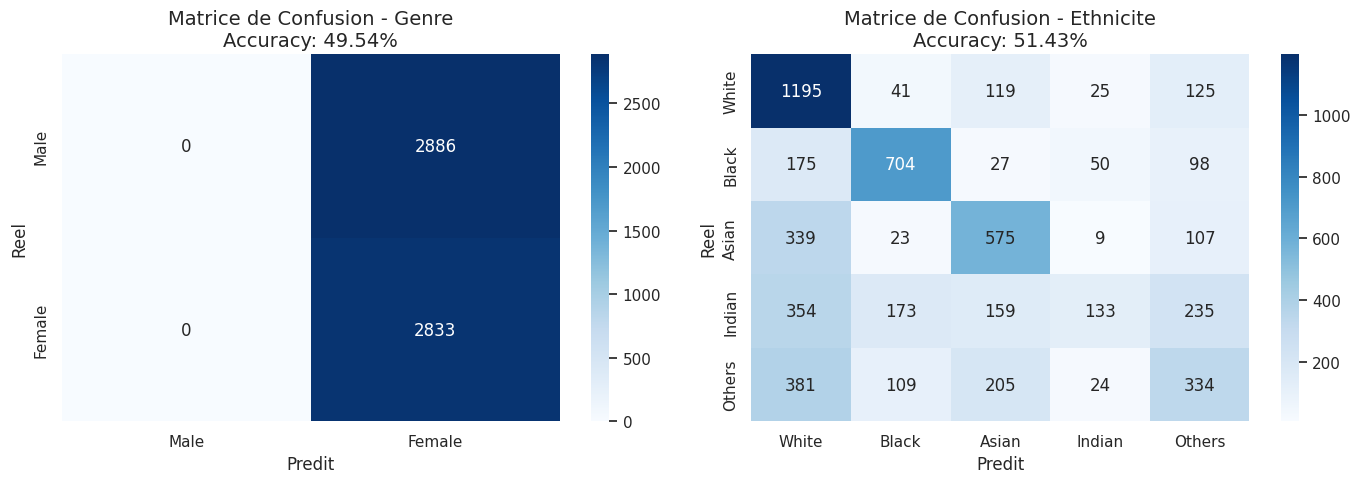

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Genre
cm_gender = confusion_matrix(y_gender_test, y_pred_gender)
sns.heatmap(
    cm_gender,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=GENDER_CLASSES,
    yticklabels=GENDER_CLASSES,
    ax=axes[0],
)
axes[0].set_xlabel("Predit")
axes[0].set_ylabel("Reel")
axes[0].set_title(f"Matrice de Confusion - Genre\nAccuracy: {acc_gender*100:.2f}%")

# Ethnicite
cm_ethnicity = confusion_matrix(y_eth_test, y_pred_ethnicity)
sns.heatmap(
    cm_ethnicity,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=ETHNICITY_CLASSES,
    yticklabels=ETHNICITY_CLASSES,
    ax=axes[1],
)
axes[1].set_xlabel("Predit")
axes[1].set_ylabel("Reel")
axes[1].set_title(
    f"Matrice de Confusion - Ethnicite\nAccuracy: {acc_ethnicity*100:.2f}%"
)

plt.tight_layout()
plt.savefig(
    ARTIFACTS_DIR / "multitask_v3_confusion_matrices.png", dpi=150, bbox_inches="tight"
)
plt.show()

## Sauvegarde du Modele


In [17]:
# Sauvegarder le modele final
final_model_path = ARTIFACTS_DIR / "multitask_v3_final.keras"
best_model.save(final_model_path)
print(f"Modele final sauvegarde: {final_model_path}")

Modele final sauvegarde: artifacts/multitask_v3_final.keras


## Conversion TFLite


In [18]:
# Conversion TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

tflite_model = converter.convert()

tflite_path = (
    ARTIFACTS_DIR / "multitask_model.tflite"
)  # Meme nom pour remplacer l'ancien
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

tflite_size_mb = tflite_path.stat().st_size / (1024 * 1024)
print(f"Modele TFLite sauvegarde: {tflite_path}")
print(f"Taille: {tflite_size_mb:.2f} MB")

INFO:tensorflow:Assets written to: /tmp/tmpacb1o_nj/assets


INFO:tensorflow:Assets written to: /tmp/tmpacb1o_nj/assets


Saved artifact at '/tmp/tmpacb1o_nj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_image')
Output Type:
  List[TensorSpec(shape=(None, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)]
Captures:
  129233004856144: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  129233004868624: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  129227406727056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129227406731088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129227406732816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129227406730704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129227406732432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129227406727824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129227406730128

W0000 00:00:1768913571.929758    5442 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1768913571.929779    5442 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1768913572.071907    5442 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


Modele TFLite sauvegarde: artifacts/multitask_model.tflite
Taille: 10.77 MB


## Metadonnees


In [19]:
import json

model_info = {
    "model_type": "multitask_v3_balanced",
    "version": "3.0",
    "img_size": IMG_SIZE,
    "input_range": [0, 255],
    "improvements": [
        "Focal Loss for class imbalance",
        "Oversampling of minority classes",
        "Reinforced class weights",
        "Enhanced data augmentation",
        "Label smoothing",
    ],
    "outputs": {
        "age": {
            "type": "regression",
            "output_name": "age_output",
            "description": "Age en annees",
        },
        "gender": {
            "type": "binary_classification",
            "output_name": "gender_output",
            "classes": GENDER_CLASSES,
            "class_map": {"0": "Male", "1": "Female"},
            "threshold": 0.5,
        },
        "ethnicity": {
            "type": "multiclass_classification",
            "output_name": "ethnicity_output",
            "classes": ETHNICITY_CLASSES,
            "class_map": {str(i): c for i, c in enumerate(ETHNICITY_CLASSES)},
        },
    },
    "metrics": {
        "age_mae": float(mae_age),
        "age_rmse": float(rmse_age),
        "gender_accuracy": float(acc_gender),
        "gender_f1": float(f1_gender),
        "ethnicity_accuracy": float(acc_ethnicity),
        "ethnicity_f1_macro": float(f1_ethnicity_macro),
        "ethnicity_f1_weighted": float(f1_ethnicity_weighted),
    },
}

info_path = ARTIFACTS_DIR / "multitask_model_info.json"
with open(info_path, "w") as f:
    json.dump(model_info, f, indent=2)

print(f"Metadonnees sauvegardees: {info_path}")
print(json.dumps(model_info, indent=2))

Metadonnees sauvegardees: artifacts/multitask_model_info.json
{
  "model_type": "multitask_v3_balanced",
  "version": "3.0",
  "img_size": 128,
  "input_range": [
    0,
    255
  ],
  "improvements": [
    "Focal Loss for class imbalance",
    "Oversampling of minority classes",
    "Reinforced class weights",
    "Enhanced data augmentation",
    "Label smoothing"
  ],
  "outputs": {
    "age": {
      "type": "regression",
      "output_name": "age_output",
      "description": "Age en annees"
    },
    "gender": {
      "type": "binary_classification",
      "output_name": "gender_output",
      "classes": [
        "Male",
        "Female"
      ],
      "class_map": {
        "0": "Male",
        "1": "Female"
      },
      "threshold": 0.5
    },
    "ethnicity": {
      "type": "multiclass_classification",
      "output_name": "ethnicity_output",
      "classes": [
        "White",
        "Black",
        "Asian",
        "Indian",
        "Others"
      ],
      "class_map"

## Resume Final


In [20]:
print("=" * 60)
print("RESUME DU MODELE MULTI-TACHE V3 (EQUILIBRE)")
print("=" * 60)
print(f"\nAmeliorations:")
print(f"  - Focal Loss pour gerer le desequilibre")
print(f"  - Oversampling des classes minoritaires")
print(f"  - Poids de classes renforces")
print(f"  - Data augmentation renforcee")
print(f"  - Label smoothing")
print(f"\nPerformances sur le test set:")
print(f"  AGE:")
print(f"     - MAE: {mae_age:.2f} annees")
print(f"     - RMSE: {rmse_age:.2f} annees")
print(f"  GENRE:")
print(f"     - Accuracy: {acc_gender*100:.2f}%")
print(f"     - F1-Score: {f1_gender:.4f}")
print(f"  ETHNICITE:")
print(f"     - Accuracy: {acc_ethnicity*100:.2f}%")
print(f"     - F1-Score (macro): {f1_ethnicity_macro:.4f}")
print(f"\nFichiers sauvegardes:")
print(f"  - {final_model_path}")
print(f"  - {tflite_path} ({tflite_size_mb:.2f} MB)")
print(f"  - {info_path}")
print("=" * 60)

RESUME DU MODELE MULTI-TACHE V3 (EQUILIBRE)

Ameliorations:
  - Focal Loss pour gerer le desequilibre
  - Oversampling des classes minoritaires
  - Poids de classes renforces
  - Data augmentation renforcee
  - Label smoothing

Performances sur le test set:
  AGE:
     - MAE: 5.88 annees
     - RMSE: 8.69 annees
  GENRE:
     - Accuracy: 49.54%
     - F1-Score: 0.6625
  ETHNICITE:
     - Accuracy: 51.43%
     - F1-Score (macro): 0.4720

Fichiers sauvegardes:
  - artifacts/multitask_v3_final.keras
  - artifacts/multitask_model.tflite (10.77 MB)
  - artifacts/multitask_model_info.json
